# 💰 Simulación de Impacto de Negocio

## Objetivo

Traducir los resultados del modelo de uplift a métricas de negocio para apoyar decisiones reales de marketing.

## Pregunta clave

¿Cuál es la mejor estrategia de targeting para maximizar el retorno económico de una campaña de email?

## Enfoque

Se compararán tres estrategias:

- Campaña masiva
- Targeting basado en modelo de clasificación (baseline)
- Targeting basado en modelo de uplift

## Métricas de evaluación

- Conversiones incrementales
- Ingreso incremental
- Costo de campaña
- Utilidad
- ROI

## Meta

Transformar el modelo en una herramienta de decisión de negocio.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [38]:
ruta_uplift = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\uplift_resultados_test.csv"
ruta_baseline = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\baseline_resultados_test.csv"

df_uplift = pd.read_csv(ruta_uplift)
df_baseline = pd.read_csv(ruta_baseline)

In [39]:
df = df_uplift.merge(
    df_baseline[['id_cliente', 'probabilidad']],
    on='id_cliente',
    how='inner'
)

df.head()

,id_cliente,recency,history_segment,history,mens,womens,zip_code,newbie,channel,tratamiento,target,prob_tratado,prob_control,uplift_estimado,decil_uplift,segmento_uplift,probabilidad
0,710,9,1) $0 - $100,35.40,0,1,Surburban,1,Web,0,0,0.269170,0.000009,0.269161,1,Persuadables,0.000349
1,2325,1,"7) $1,000 +",1249.70,1,1,Surburban,1,Multichannel,1,0,0.232918,0.002475,0.230443,1,Persuadables,0.000308
2,49,10,1) $0 - $100,61.09,0,1,Surburban,0,Web,1,0,0.185974,0.000108,0.185866,1,Persuadables,0.000310
3,890,10,2) $100 - $200,167.85,0,1,Surburban,0,Web,1,0,0.170296,0.000020,0.170276,1,Persuadables,0.000279
4,39172,1,"7) $1,000 +",1447.55,1,1,Urban,1,Web,1,0,0.168711,0.003466,0.165245,1,Persuadables,0.000177


In [40]:
print(df.shape)
df.isnull().sum()

(5774, 17)


id_cliente         0
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
tratamiento        0
target             0
prob_tratado       0
prob_control       0
uplift_estimado    0
decil_uplift       0
segmento_uplift    0
probabilidad       0
dtype: int64

In [41]:
costo_por_email = 0.05
ticket_promedio = 60.00
margen = 0.30

ingreso_por_conversion = ticket_promedio * margen

print("Ingreso por conversión:", round(ingreso_por_conversion, 2))

Ingreso por conversión: 18.0


In [42]:
def evaluar_estrategia(df, columna_score, proporcion, nombre):

    n = int(len(df) * proporcion)

    df_top = df.sort_values(by=columna_score, ascending=False).head(n)

    conv_trat = df_top[df_top['tratamiento'] == 1]['target'].mean()
    conv_ctrl = df_top[df_top['tratamiento'] == 0]['target'].mean()

    uplift = conv_trat - conv_ctrl

    conv_incrementales = uplift * n
    ingreso = conv_incrementales * ingreso_por_conversion
    costo = n * costo_por_email
    utilidad = ingreso - costo

    roi = utilidad / costo if costo != 0 else 0

    return {
        'estrategia': nombre,
        'proporcion': round(proporcion, 2),
        'clientes': n,
        'uplift': round(uplift, 2),
        'conv_incrementales': round(conv_incrementales, 2),
        'ingreso': round(ingreso, 2),
        'costo': round(costo, 2),
        'utilidad': round(utilidad, 2),
        'roi': round(roi, 2)
    }

In [43]:
proporciones = [0.1, 0.2, 0.3, 0.5, 1.0]

In [44]:
res_uplift = pd.DataFrame([
    evaluar_estrategia(df, 'uplift_estimado', p, 'Modelo uplift')
    for p in proporciones
])

res_uplift

,estrategia,proporcion,clientes,uplift,conv_incrementales,ingreso,costo,utilidad,roi
0,Modelo uplift,0.1,577,0.02,10.94,196.93,28.85,168.08,5.83
1,Modelo uplift,0.2,1154,0.01,9.12,164.22,57.70,106.52,1.85
2,Modelo uplift,0.3,1732,0.01,8.87,159.67,86.60,73.07,0.84
3,Modelo uplift,0.5,2887,0.01,23.19,417.38,144.35,273.03,1.89
4,Modelo uplift,1.0,5774,0.00,27.16,488.92,288.70,200.22,0.69


In [45]:
res_baseline = pd.DataFrame([
    evaluar_estrategia(df, 'probabilidad', p, 'Baseline')
    for p in proporciones
])

res_baseline

,estrategia,proporcion,clientes,uplift,conv_incrementales,ingreso,costo,utilidad,roi
0,Baseline,0.1,577,0.10,56.50,1017.01,28.85,988.16,34.25
1,Baseline,0.2,1154,0.05,54.03,972.48,57.70,914.78,15.85
2,Baseline,0.3,1732,0.03,50.73,913.15,86.60,826.55,9.54
3,Baseline,0.5,2887,0.01,40.56,730.12,144.35,585.77,4.06
4,Baseline,1.0,5774,0.00,27.16,488.92,288.70,200.22,0.69


In [46]:
res_masivo = evaluar_estrategia(df, 'uplift_estimado', 1.0, 'Campaña masiva')
res_masivo = pd.DataFrame([res_masivo])

res_masivo

,estrategia,proporcion,clientes,uplift,conv_incrementales,ingreso,costo,utilidad,roi
0,Campaña masiva,1.0,5774,0.0,27.16,488.92,288.7,200.22,0.69


In [47]:
res_total = pd.concat([res_uplift, res_baseline], ignore_index=True)

res_total

,estrategia,proporcion,clientes,uplift,conv_incrementales,ingreso,costo,utilidad,roi
0,Modelo uplift,0.1,577,0.02,10.94,196.93,28.85,168.08,5.83
1,Modelo uplift,0.2,1154,0.01,9.12,164.22,57.70,106.52,1.85
2,Modelo uplift,0.3,1732,0.01,8.87,159.67,86.60,73.07,0.84
3,Modelo uplift,0.5,2887,0.01,23.19,417.38,144.35,273.03,1.89
4,Modelo uplift,1.0,5774,0.00,27.16,488.92,288.70,200.22,0.69
5,Baseline,0.1,577,0.10,56.50,1017.01,28.85,988.16,34.25
6,Baseline,0.2,1154,0.05,54.03,972.48,57.70,914.78,15.85
7,Baseline,0.3,1732,0.03,50.73,913.15,86.60,826.55,9.54
8,Baseline,0.5,2887,0.01,40.56,730.12,144.35,585.77,4.06
9,Baseline,1.0,5774,0.00,27.16,488.92,288.70,200.22,0.69


In [48]:
res_total.sort_values(by='utilidad', ascending=False)

,estrategia,proporcion,clientes,uplift,conv_incrementales,ingreso,costo,utilidad,roi
5,Baseline,0.1,577,0.10,56.50,1017.01,28.85,988.16,34.25
6,Baseline,0.2,1154,0.05,54.03,972.48,57.70,914.78,15.85
7,Baseline,0.3,1732,0.03,50.73,913.15,86.60,826.55,9.54
8,Baseline,0.5,2887,0.01,40.56,730.12,144.35,585.77,4.06
3,Modelo uplift,0.5,2887,0.01,23.19,417.38,144.35,273.03,1.89
4,Modelo uplift,1.0,5774,0.00,27.16,488.92,288.70,200.22,0.69
9,Baseline,1.0,5774,0.00,27.16,488.92,288.70,200.22,0.69
0,Modelo uplift,0.1,577,0.02,10.94,196.93,28.85,168.08,5.83
1,Modelo uplift,0.2,1154,0.01,9.12,164.22,57.70,106.52,1.85
2,Modelo uplift,0.3,1732,0.01,8.87,159.67,86.60,73.07,0.84


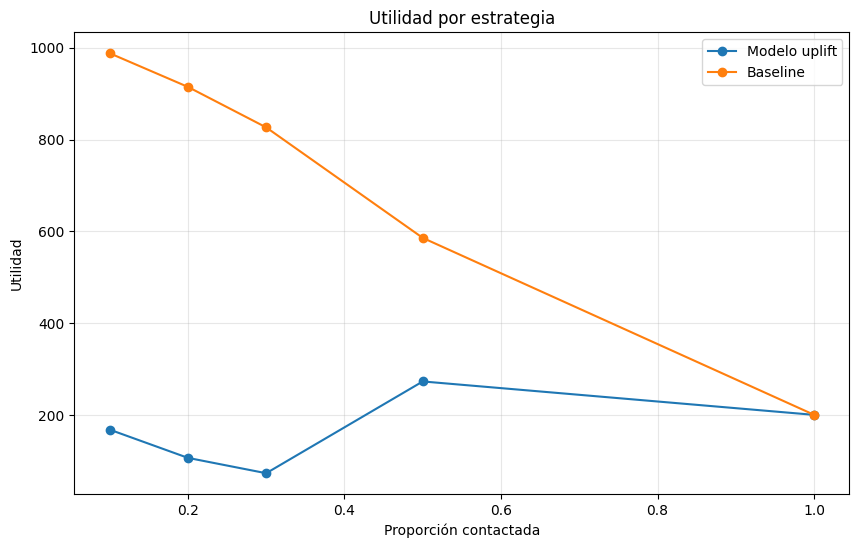

In [49]:
plt.figure(figsize=(10,6))

for est in res_total['estrategia'].unique():
    temp = res_total[res_total['estrategia'] == est]
    plt.plot(temp['proporcion'], temp['utilidad'], marker='o', label=est)

plt.title("Utilidad por estrategia")
plt.xlabel("Proporción contactada")
plt.ylabel("Utilidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

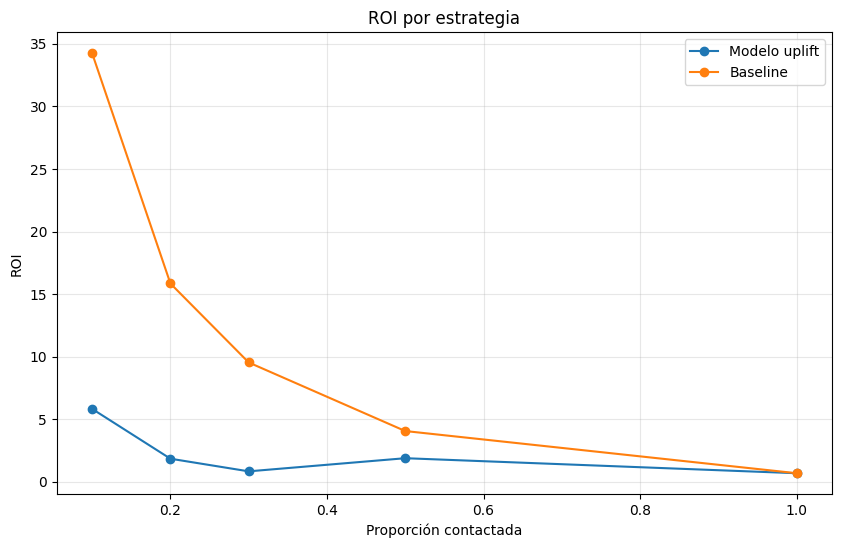

In [50]:
plt.figure(figsize=(10,6))

for est in res_total['estrategia'].unique():
    temp = res_total[res_total['estrategia'] == est]
    plt.plot(temp['proporcion'], temp['roi'], marker='o', label=est)

plt.title("ROI por estrategia")
plt.xlabel("Proporción contactada")
plt.ylabel("ROI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

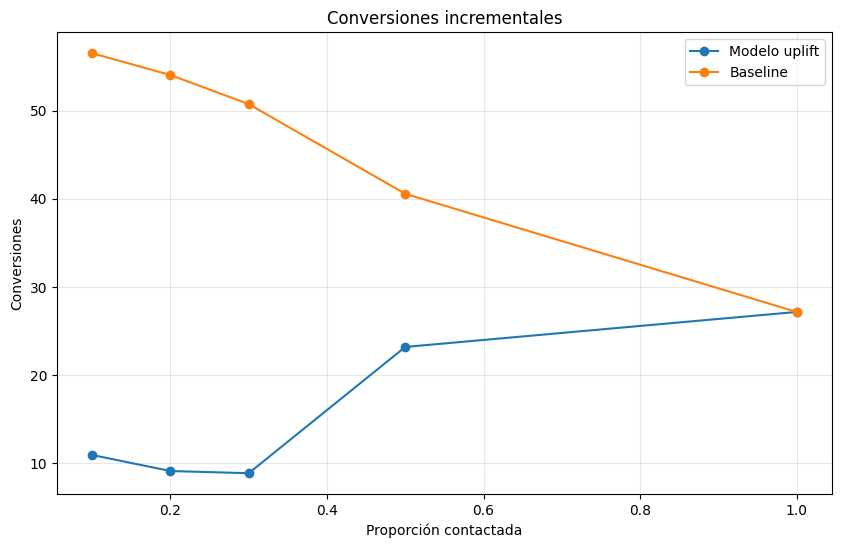

In [51]:
plt.figure(figsize=(10,6))

for est in res_total['estrategia'].unique():
    temp = res_total[res_total['estrategia'] == est]
    plt.plot(temp['proporcion'], temp['conv_incrementales'], marker='o', label=est)

plt.title("Conversiones incrementales")
plt.xlabel("Proporción contactada")
plt.ylabel("Conversiones")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
ruta = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\resultado_negocio.csv"

res_total.to_csv(ruta, index=False)

## Resultados

- El modelo de uplift permite priorizar clientes con mayor impacto incremental esperado.
- Estrategias de targeting selectivo pueden superar campañas masivas en términos de utilidad y ROI.
- El baseline basado en probabilidad no necesariamente maximiza impacto económico.

## Hallazgo clave

La mejor estrategia no es contactar a todos los clientes, sino seleccionar aquellos con mayor uplift.

## Implicación

El modelo permite transformar campañas de marketing en decisiones óptimas de asignación de recursos.